# Modelación en ingeniería
## Modelo Lotka-Volterra: no lineal vs. linealizado

*Profesor: David Ortiz-Puerta*

---

Comparación del modelo presa-depredador de Lotka-Volterra no lineal y su linealización alrededor del equilibrio de coexistencia $(1, 1)$, evaluando la respuesta de ambos ante distintas señales de entrada (escalón, multiseno, PRBS y chirp) aplicadas como perturbación sobre la tasa de captura $\beta$.

**Objetivos de aprendizaje**

- Linealizar un sistema no lineal con entrada alrededor de un punto de equilibrio y obtener su representación en espacio de estados.
- Identificar el rango de validez de la aproximación lineal contrastando trayectorias con el modelo no lineal.
- Reconocer cómo distintas señales de entrada excitan la dinámica y revelan los efectos no lineales.

> **💡 Nota para usuarios de Google Colab**
> 
> Antes de ejecutar el notebook, descarga las funciones auxiliares ejecutando la siguiente celda

In [81]:
# !wget -q https://raw.githubusercontent.com/dortiz5/modelacion-en-ingenieria/main/Notebooks/helpers.py

In [82]:
import sys
sys.path.append('..')   # sube un nivel, ahora ve 'src' como paquete
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from Notebooks.helpers import (save_simulation, configure_plot_style, generate_input)

configure_plot_style()

## Modelo de Lotka-Volterra

El modelo de Lotka-Volterra describe la interacción entre dos especies en un sistema presa-depredador. Sea $x_1(t)$ la población de presas y $x_2(t)$ la de depredadores. La dinámica se rige por:

\begin{equation*}
\begin{aligned}
\dot{x}_1 &= \alpha x_1 - \beta x_1 x_2 \\
\dot{x}_2 &= \delta x_1 x_2 - \gamma x_2
\end{aligned}
\end{equation*}

donde $\alpha$ es la tasa de crecimiento de la presa en ausencia de depredador, $\gamma$ la tasa de mortalidad del depredador en ausencia de presa, y $\beta$, $\delta$ los coeficientes de interacción trófica. Para este trabajo se usan parámetros canónicos $\alpha = \beta = \gamma = \delta = 1$.

La entrada $u(t)$ se introduce como una perturbación sobre la tasa de captura $\beta$, modelando una intervención externa (cosecha, pesticida, refugio) que afecta únicamente el lado de la presa sin alterar la eficiencia de conversión del depredador:

\begin{equation*}
\begin{aligned}
\dot{x}_1 &= \alpha x_1 - (\beta + u(t)) \, x_1 x_2 \\
\dot{x}_2 &= \delta x_1 x_2 - \gamma x_2
\end{aligned}
\end{equation*}

El sistema posee dos puntos de equilibrio: el trivial $(0,0)$ y el no trivial $(x_1^*, x_2^*) = (\gamma/\delta, \, \alpha/\beta) = (1, 1)$. Este último corresponde al régimen de coexistencia y es el punto de operación de interés para identificación.

### Linealización en el equilibrio

Sean las variables de desviación $\Delta x_i = x_i - x_{i,0}$. Linealizando el sistema forzado alrededor de $(x_{1,0}, x_{2,0})$ se obtiene:

$$
\Delta\dot{x}_1 = -\beta x_{1,0}\,\Delta x_2 - x_{1,0} x_{2,0}\,\Delta u
$$
$$
\Delta\dot{x}_2 = \delta x_{2,0}\,\Delta x_1
$$

En forma matricial:

$$
\begin{bmatrix} \Delta\dot{x}_1 \\ \Delta\dot{x}_2 \end{bmatrix}
=
\underbrace{\begin{bmatrix} 0 & -\beta x_{1,0} \\ \delta x_{2,0} & 0 \end{bmatrix}}_{A}
\begin{bmatrix} \Delta x_1 \\ \Delta x_2 \end{bmatrix}
+
\underbrace{\begin{bmatrix} -x_{1,0} x_{2,0} \\ 0 \end{bmatrix}}_{B}
\Delta u
$$

El polinomio característico de $A$ es

\begin{equation*}
\lambda^2 + \beta\delta\, x_{1,0} x_{2,0} = 0,
\end{equation*}

que evaluado en el equilibrio $(x_{1,0}, x_{2,0}) = (\gamma/\delta,\, \alpha/\beta)$ da autovalores puramente imaginarios $\lambda_{1,2} = \pm j\sqrt{\alpha\gamma}$. El equilibrio es por tanto un **centro**: el modelo lineal predice oscilaciones sostenidas de frecuencia natural $\omega_n = \sqrt{\alpha\gamma}$, sin amortiguamiento. El término $-x_{1,0} x_{2,0}\,\Delta u$ aparece en la ecuación de $\Delta\dot{x}_1$ porque la entrada multiplica al producto $x_1 x_2$, cuyo valor en el equilibrio es no nulo.

> **💡 ¡Observación!**  
> El punto de operación se define con entrada nominal $u_0 = 0$ (es decir, $\beta$ sin perturbar). Como la desviación se mide respecto a ese valor, $\Delta u(t) = u(t) - u_0 = u(t)$. No es una identidad general: es consecuencia de haber elegido $u_0 = 0$ al construir el modelo linealizado.

La linealización es válida solo en una vecindad del equilibrio.

In [83]:
def simulate_lotka_volterra(x0, t, sigma_noise=0.0, u=None, linear=False,
                             save=False, data_dir='../data', title = None):
    alpha, beta, gamma, delta = 1.0, 1.0, 1.0, 1.0
    x1_eq, x2_eq = gamma/delta, alpha/beta

    if u is None:
        u = np.zeros_like(t)
    u_interp = lambda ti: np.interp(ti, t, u)

    if linear:
        def rhs(ti, x):
            x1t, x2t = x
            ut = u_interp(ti)
            dx1 = -beta * x1_eq * x2t - x1_eq * x2_eq * ut
            dx2 = delta * x2_eq * x1t
            return [dx1, dx2]
        x0_sim = [x0[0] - x1_eq, x0[1] - x2_eq]
    else:
        def rhs(ti, x):
            x1, x2 = x
            ut = u_interp(ti)
            dx1 = alpha*x1 - (beta + ut)*x1*x2
            dx2 = delta*x1*x2 - gamma*x2
            return [dx1, dx2]
        x0_sim = x0

    sol = solve_ivp(rhs, (t[0], t[-1]), x0_sim, t_eval=t,
                    method='RK45', rtol=1e-8, atol=1e-10)

    x1, x2 = sol.y
    if linear:
        x1 = x1 + x1_eq
        x2 = x2 + x2_eq

    if sigma_noise > 0:
        x1 = x1 + np.random.normal(0, sigma_noise, size=x1.shape)
        x2 = x2 + np.random.normal(0, sigma_noise, size=x2.shape)

    df = pd.DataFrame({'t': t, 'u': u, 'x1': x1, 'x2': x2})

    if save:
        model_name = 'lotka_volterra_linear' if linear else 'lotka_volterra'
        if title:                                # None o '' es Falsy
            model_name = f'{model_name}_{title}'
        filepath = save_simulation(df, model_name, data_dir)
        print(f'Saved: {filepath}')

    return df

Simulación con difenrentes entradas

Saved: ../data/lotka_volterra/lotka_volterra_20260607_001.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260607_001.csv


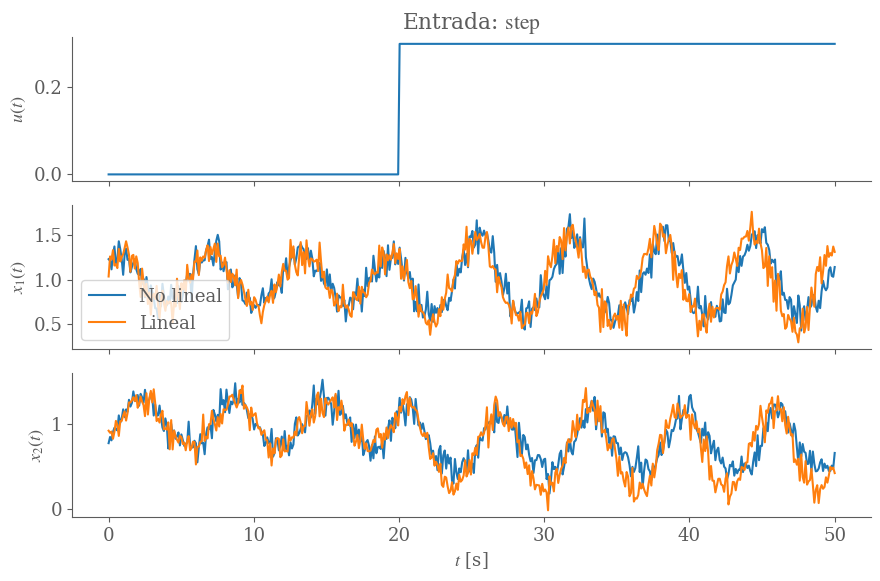

Saved: ../data/lotka_volterra/lotka_volterra_20260607_002.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260607_002.csv


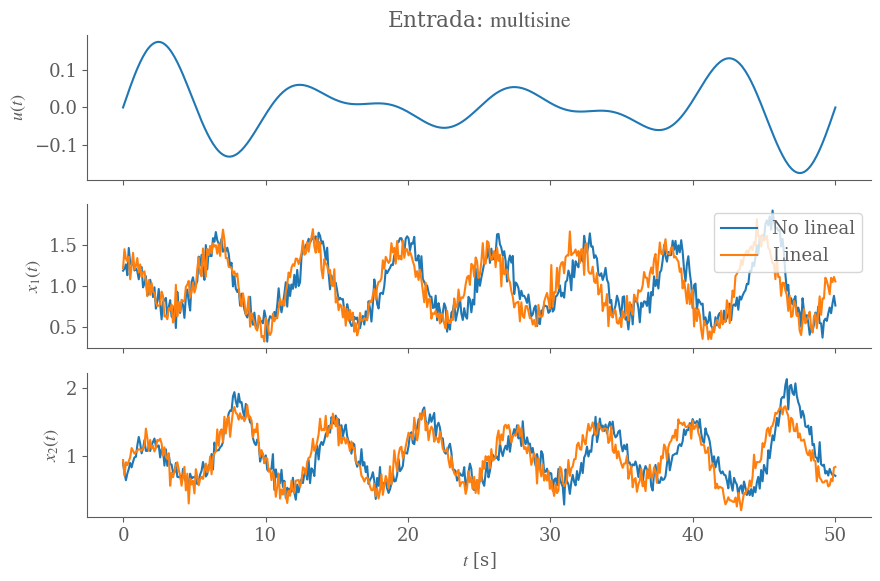

Saved: ../data/lotka_volterra/lotka_volterra_20260607_003.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260607_003.csv


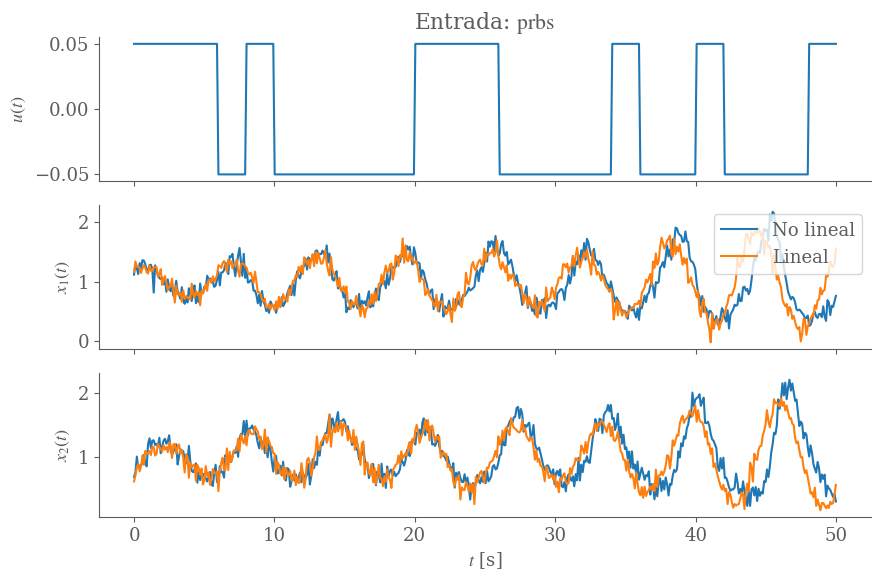

Saved: ../data/lotka_volterra/lotka_volterra_20260607_004.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260607_004.csv


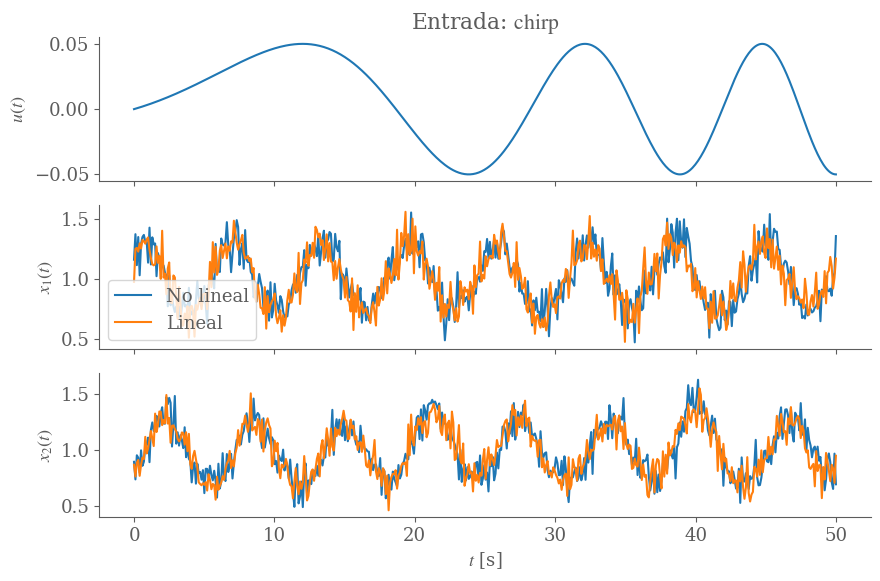

Saved: ../data/lotka_volterra/lotka_volterra_20260607_005.csv
Saved: ../data/lotka_volterra_linear/lotka_volterra_linear_20260607_005.csv


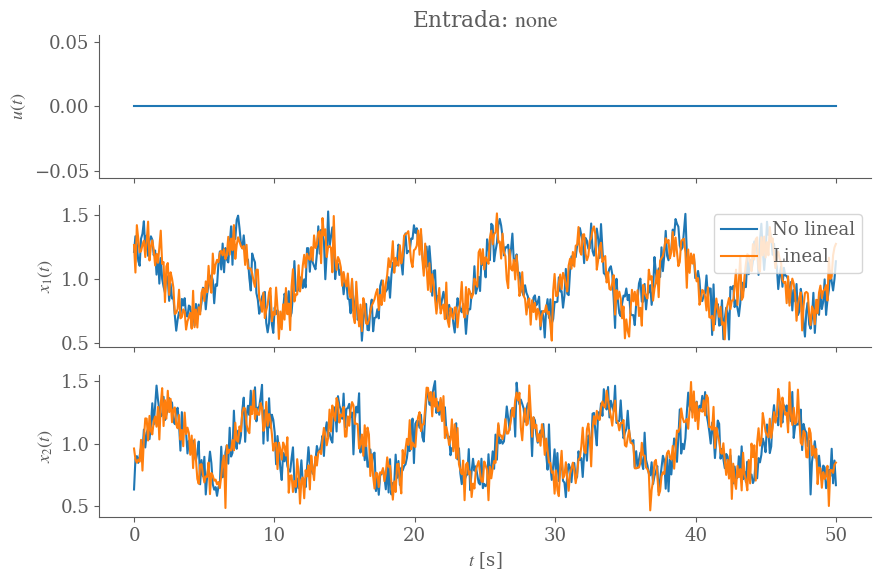

In [84]:
t = np.linspace(0, 50, 500)

u_step      = generate_input(t, 'step', t_step=20, u0=0, u1=0.3)
u_multisine = generate_input(t, 'multisine', freqs=[0.08, 0.1, 0.12], 
                                             amps=[0.07, 0.06, 0.05])
u_prbs      = generate_input(t, 'prbs', n_bits=8, t_bit=2, amplitude=0.05, seed=42)
u_chirp     = generate_input(t, 'chirp', f0=0.01, f1=0.1, amplitude=0.05)
u_none      = generate_input(t, 'none')

inputs = {'step': u_step, 'multisine': u_multisine,
          'prbs': u_prbs, 'chirp': u_chirp, 'none': u_none}

for name, u in inputs.items():
    df_nl = simulate_lotka_volterra(x0=[1.2, 0.8], t=t, sigma_noise=0.1, u=u, 
                                    linear=False, save=True)
    df_l  = simulate_lotka_volterra(x0=[1.2, 0.8], t=t, sigma_noise=0.1, u=u, 
                                    linear=True, save=True)

    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(df_nl['t'], df_nl['u']); axes[0].set_ylabel(r'$u(t)$'); axes[0].set_title(rf'Entrada: $\mathrm{{{name}}}$')
    axes[1].plot(df_nl['t'], df_nl['x1'], label='No lineal')
    axes[1].plot(df_l['t'],  df_l['x1'],  '-', label='Lineal')
    axes[1].set_ylabel(r'$x_1(t)$'); axes[1].legend()
    axes[2].plot(df_nl['t'], df_nl['x2'], label='No lineal')
    axes[2].plot(df_l['t'],  df_l['x2'], '-', label='Lineal')
    axes[2].set_ylabel(r'$x_2(t)$'); axes[2].set_xlabel(r'$t$ [s]')
    plt.tight_layout(); plt.show()

### Rango de validez de la linealización

La aproximación lineal es válida solo en una vecindad del equilibrio. Para cuantificar esta vecindad, se define un experimento sin entrada ($u(t) = 0$) en el que ambos modelos parten de la misma condición inicial $x_0 = (1 + \varepsilon,\, 1 + \varepsilon)$, con $\varepsilon$ una desviación uniforme respecto al equilibrio $(1, 1)$. Para cada valor de $\varepsilon$ se calcula el error relativo en norma $L^2$ entre la órbita no lineal y la lineal:

\begin{equation}
E_i(\varepsilon) = \frac{\|x_i^{\text{nl}}(t) - x_i^{\text{lin}}(t)\|_2}{\|x_i^{\text{nl}}(t)\|_2}, \quad i = 1, 2.
\end{equation}

Barriendo $\varepsilon$ se obtiene la curva $E_i(\varepsilon)$, cuya intersección con el umbral del $10\%$ define el rango de operación dentro del cual la linealización es razonable para fines de identificación.

> **📚 Ejercicio:**  
> Identifica el valor crítico $\varepsilon^*$ tal que $E_i(\varepsilon^*) \approx 0.1$. ¿El rango es simétrico respecto al equilibrio? ¿Por qué $E_1$ y $E_2$ podrían no coincidir?

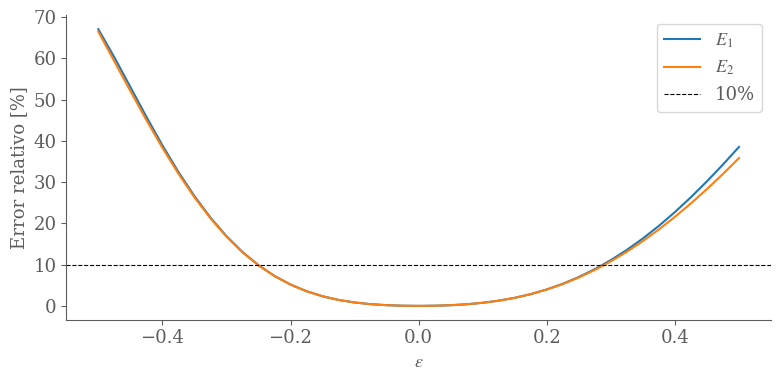

In [85]:
eps_range = np.linspace(-0.5, 0.5, 41)
errors = np.zeros((len(eps_range), 2))

for k, eps in enumerate(eps_range):
    x0 = [1 + eps, 1 + eps]
    df_nl = simulate_lotka_volterra(x0, t, sigma_noise=0.0, linear=False)
    df_l  = simulate_lotka_volterra(x0, t, sigma_noise=0.0, linear=True)
    for i, var in enumerate(['x1', 'x2']):
        errors[k, i] = np.linalg.norm(df_nl[var] - df_l[var]) / np.linalg.norm(df_nl[var])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eps_range, errors[:, 0]*100, label=r'$E_1$')
ax.plot(eps_range, errors[:, 1]*100, label=r'$E_2$')
ax.axhline(10, color='k', ls='--', lw=0.8, label='10%')
ax.set_xlabel(r'$\varepsilon$'); ax.set_ylabel('Error relativo [%]')
ax.legend(); plt.tight_layout(); plt.show()